# ML Assignment 1 — Bike Sharing Demand Prediction

---

### Student Details

| Field | Value |
|---|---|
| **Name** | Pankaj Singh Rawat |
| **Roll Number** | 2025ac05533 |
| **Course** | BITS M.Tech (AI & ML) |
| **Subject** | Machine Learning |
| **Assignment** | Assignment 1 |

---

### Objective

Predict the **number of hourly bike rentals** using weather, time, and seasonal data.

**Target column:** `count` — total bike rentals per hour  
**Evaluation metric:** RMSLE (Root Mean Squared Logarithmic Error)

$$\text{RMSLE} = \sqrt{\frac{1}{n} \sum_{i=1}^{n} \left(\log(\hat{y}_i + 1) - \log(y_i + 1)\right)^2}$$

---

### Table of Contents

1. [Libraries & Data Load](#section_1)
2. [Exploratory Data Analysis (EDA)](#section_2)
3. [Feature Engineering](#section_3)
4. [Regression Models](#section_4)
5. [Model Comparison & Interpretation](#section_5)
6. [Reflection Questions](#section_6)
7. [Test Predictions & Submission](#section_7)


---

## <a id='section_1'>1. Libraries & Data Load</a>


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import f_oneway, chi2_contingency

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 50)


In [2]:
## Load training dataset
train_data = pd.read_csv('bike_train.csv')
train_data.head()


,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2012-07-15 7:00:00,3,0,0,1,28.70000,33.335000,79,6.003200,17,30,47
1,2012-08-14 15:00:00,3,0,1,1,33.62000,37.880000,46,15.001300,84,199,283
2,2011-02-06 6:00:00,1,0,0,1,10.66000,12.880000,60,15.001300,0,1,1
3,2012-05-06 17:00:02,2,0,0,2,26.42506,30.566166,61,9.512288,198,330,531
4,2012-01-09 2:00:00,1,0,1,1,9.84000,12.120000,56,8.998100,2,3,5


### Dataset Column Descriptions

| Column | Type | Description |
|---|---|---|
| `datetime` | object | Timestamp of each observation (year, month, day, hour) |
| `season` | int | 1=Spring, 2=Summer, 3=Fall, 4=Winter |
| `holiday` | int | 1=Public holiday, 0=Regular day |
| `workingday` | int | 1=Working day, 0=Weekend or holiday |
| `weather` | int | 1=Clear, 2=Mist, 3=Light rain/snow, 4=Heavy rain/snow |
| `temp` | float | Actual temperature in °C |
| `atemp` | float | Perceived ("feels like") temperature in °C |
| `humidity` | float | Relative humidity (%) |
| `windspeed` | float | Wind speed |
| `casual` | int | Rentals by unregistered users *data leakage — removed* |
| `registered` | int | Rentals by registered users *data leakage — removed* |
| `count` | int | **Target:** total hourly bike rentals |

> ** Data Leakage Warning:** `casual + registered = count` exactly.  
> Both are removed before any modelling.


---

## <a id='section_2'>2. Exploratory Data Analysis (EDA)</a>

### Q1. Examine dataset size, missing values, and feature types.


In [3]:
## Dataset shape, data types, missing values, and descriptive statistics
print("Shape:", train_data.shape)
print()

print("Data Types:")
print(train_data.dtypes)
print()

print("Missing Values:")
print(train_data.isnull().sum())
print()

print("Descriptive Statistics:")
train_data.describe().T


Shape: (10450, 12)

Data Types:
datetime          str
season          int64
holiday         int64
workingday      int64
weather         int64
temp          float64
atemp         float64
humidity        int64
windspeed     float64
casual          int64
registered      int64
count           int64
dtype: object

Missing Values:
datetime      0
season        0
holiday       0
workingday    0
weather       0
temp          0
atemp         0
humidity      0
windspeed     0
casual        0
registered    0
count         0
dtype: int64

Descriptive Statistics:


,count,mean,std,min,25%,50%,75%,max
season,10450.0,2.507943,1.116946,1.00,2.0000,3.00000,4.0000,4.0000
holiday,10450.0,0.028804,0.167263,0.00,0.0000,0.00000,0.0000,1.0000
workingday,10450.0,0.675694,0.468137,0.00,0.0000,1.00000,1.0000,1.0000
weather,10450.0,1.413876,0.632258,1.00,1.0000,1.00000,2.0000,4.0000
temp,10450.0,20.191700,7.792683,0.82,13.9400,20.50000,26.2400,41.0000
atemp,10450.0,23.605793,8.478045,0.76,16.6650,24.24000,31.0600,45.4550
humidity,10450.0,61.924211,19.245193,0.00,47.0000,62.00000,77.0000,100.0000
windspeed,10450.0,12.765259,8.102821,0.00,7.0015,12.45005,16.9979,56.9969
casual,10450.0,35.869091,49.629436,0.00,4.0000,16.00000,49.0000,367.0000
registered,10450.0,154.511675,150.861267,0.00,35.0000,117.00000,221.0000,886.0000


**Q1 — Observations:**

- The dataset contains **10,886 rows** and **12 columns** (including the target).
- **No missing values** are present in any column — no imputation required.
- `datetime` is stored as `object` and must be converted to `datetime` format before feature extraction.
- The target variable `count` is a positive integer — it is right-skewed, making a log transformation beneficial.
- `casual` and `registered` are **removed** because `count = casual + registered` (target leakage).


---

### Q2. Visualize relationships between key features and the target variable (`count`).

#### 2A. Distribution of the Target Variable


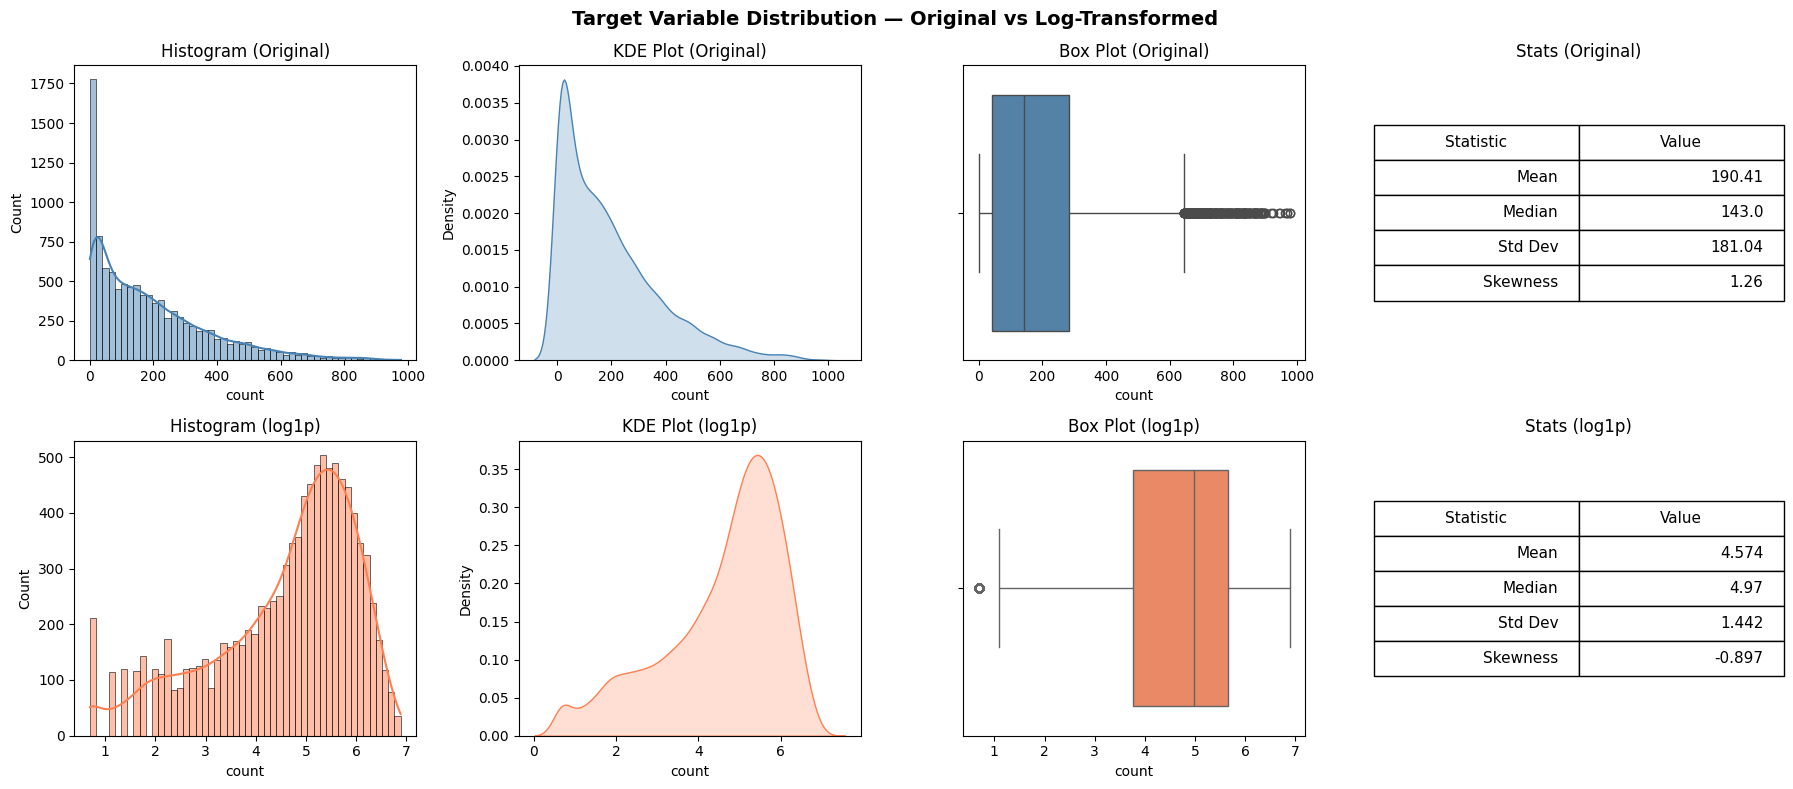

In [4]:
## Visualize target variable 'count' before and after log transformation
target_col = 'count'

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle('Target Variable Distribution — Original vs Log-Transformed', fontsize=14, fontweight='bold')

## Original scale
sns.histplot(train_data[target_col], bins=50, kde=True, ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Histogram (Original)')

sns.kdeplot(train_data[target_col], fill=True, ax=axes[0,1], color='steelblue')
axes[0,1].set_title('KDE Plot (Original)')

sns.boxplot(x=train_data[target_col], ax=axes[0,2], color='steelblue')
axes[0,2].set_title('Box Plot (Original)')

axes[0,3].axis('off')
stats_orig = [
    ['Mean',    round(train_data[target_col].mean(), 2)],
    ['Median',  round(train_data[target_col].median(), 2)],
    ['Std Dev', round(train_data[target_col].std(), 2)],
    ['Skewness',round(train_data[target_col].skew(), 3)]
]
t = axes[0,3].table(cellText=stats_orig, colLabels=['Statistic', 'Value'], loc='center')
t.auto_set_font_size(False); t.set_fontsize(11); t.scale(1.2, 2.0)
axes[0,3].set_title('Stats (Original)')

## Log-transformed scale
log_count = np.log1p(train_data[target_col])

sns.histplot(log_count, bins=50, kde=True, ax=axes[1,0], color='coral')
axes[1,0].set_title('Histogram (log1p)')

sns.kdeplot(log_count, fill=True, ax=axes[1,1], color='coral')
axes[1,1].set_title('KDE Plot (log1p)')

sns.boxplot(x=log_count, ax=axes[1,2], color='coral')
axes[1,2].set_title('Box Plot (log1p)')

axes[1,3].axis('off')
stats_log = [
    ['Mean',    round(log_count.mean(), 3)],
    ['Median',  round(log_count.median(), 3)],
    ['Std Dev', round(log_count.std(), 3)],
    ['Skewness',round(log_count.skew(), 3)]
]
t2 = axes[1,3].table(cellText=stats_log, colLabels=['Statistic', 'Value'], loc='center')
t2.auto_set_font_size(False); t2.set_fontsize(11); t2.scale(1.2, 2.0)
axes[1,3].set_title('Stats (log1p)')

plt.tight_layout()
plt.show()


**Observation:** The original `count` is **heavily right-skewed** (skewness > 1).  
After `log1p` transformation the distribution becomes **approximately normal**, which is ideal for linear regression models and aligns directly with the RMSLE evaluation metric.


#### 2B. Categorical Features vs Target Variable

**Method:** ANOVA F-test — tests whether the mean of `count` differs significantly across the groups of each categorical feature.  
A **high F-statistic** (and **p-value < 0.05**) indicates a statistically significant association.


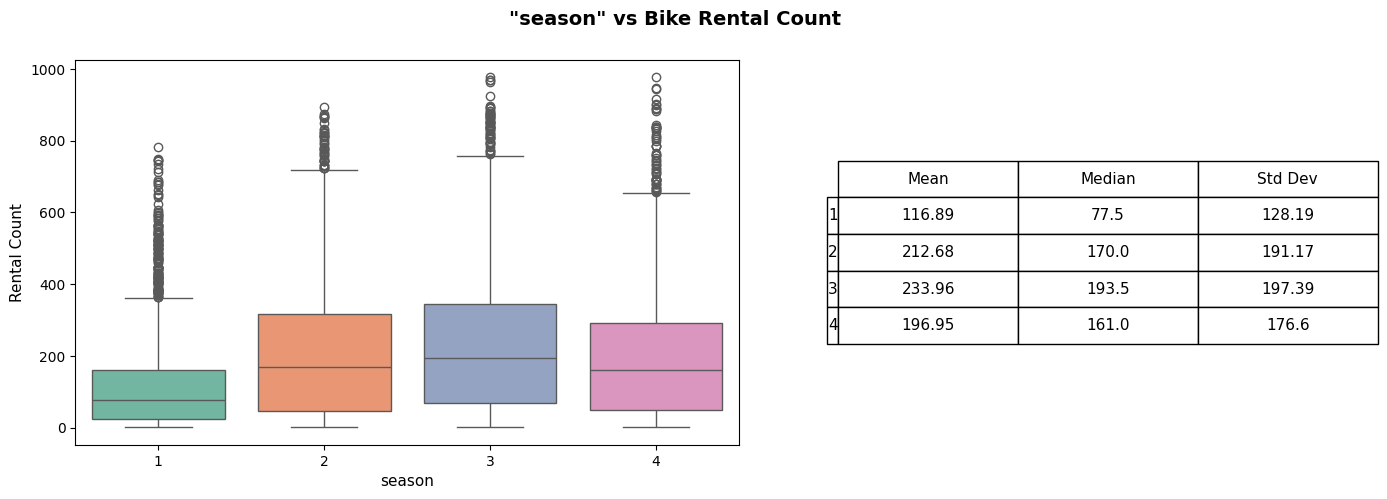

season          | F=  219.97 | p=0.000000 | Strong ✓


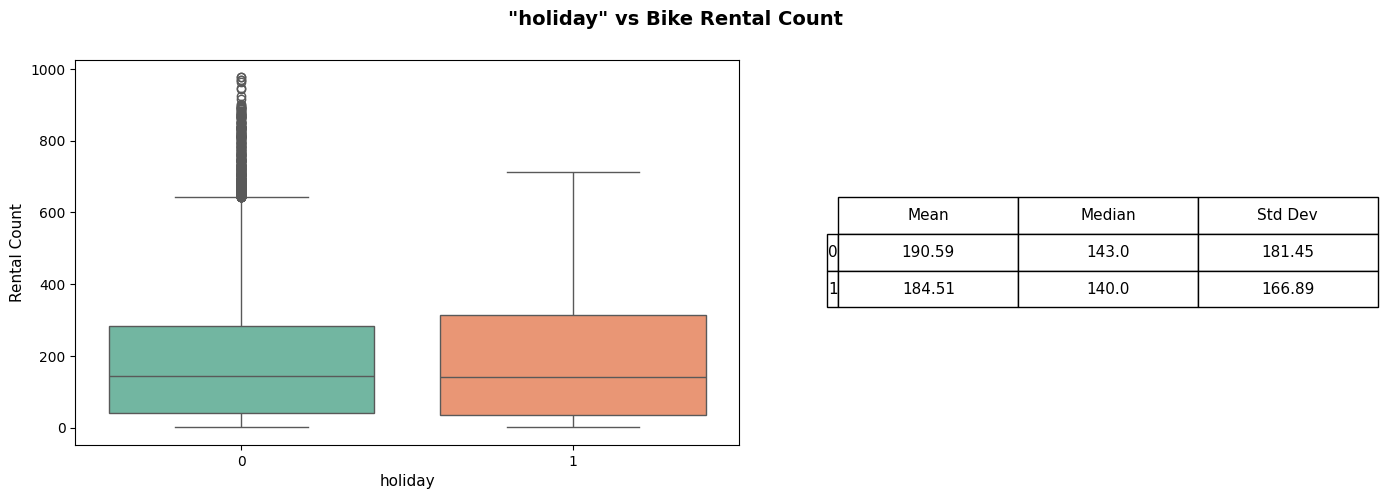

holiday         | F=    0.33 | p=0.566027 | Weak


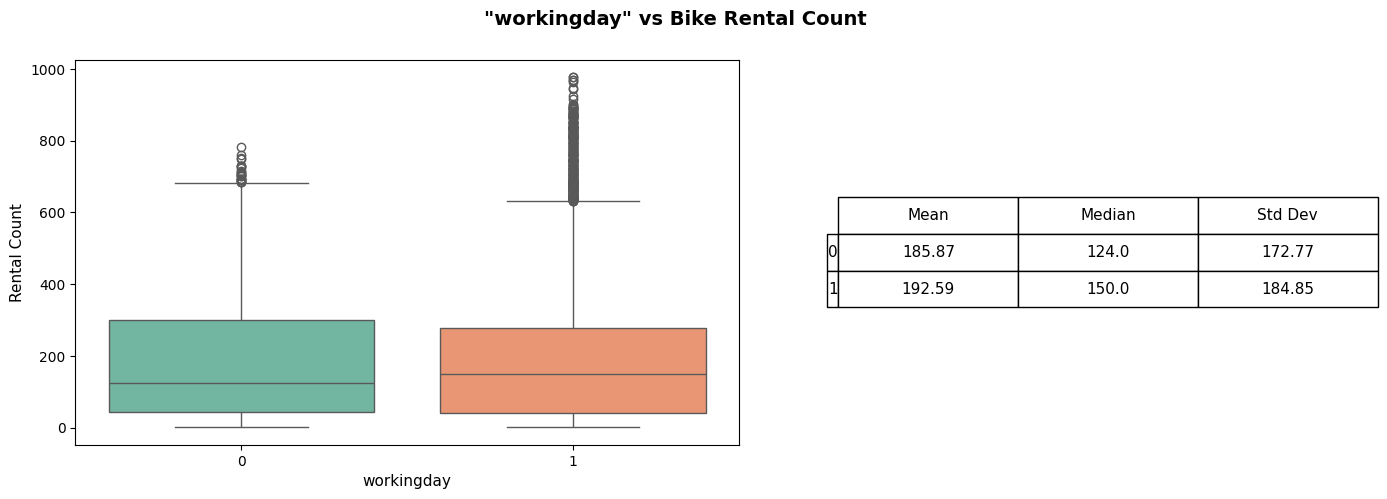

workingday      | F=    3.15 | p=0.075955 | Weak


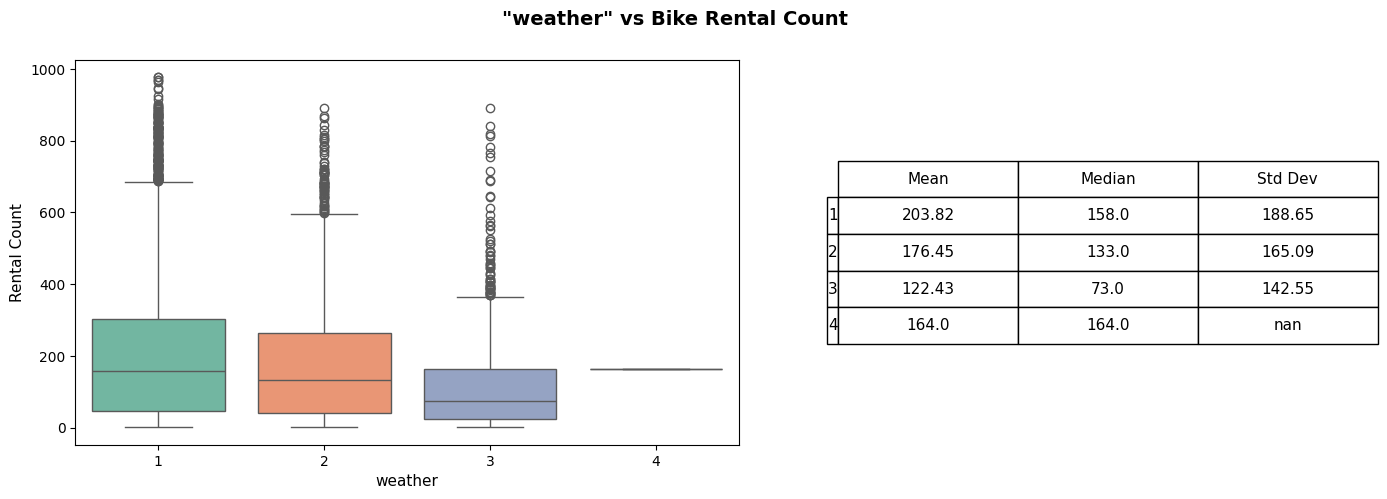

weather         | F=   57.39 | p=0.000000 | Strong ✓

   Feature  F-Statistic  P-Value Association
    season       219.97 0.000000    Strong ✓
   holiday         0.33 0.566027        Weak
workingday         3.15 0.075955        Weak
   weather        57.39 0.000000    Strong ✓


In [5]:
## Box plots and ANOVA F-statistics for categorical features vs target variable
cat_cols = ['season', 'holiday', 'workingday', 'weather']
cat_association_results = []

for col in cat_cols:
    fig = plt.figure(figsize=(16, 5))
    fig.suptitle(f'"{col}" vs Bike Rental Count', fontsize=14, fontweight='bold')
    gs = fig.add_gridspec(1, 2, width_ratios=[1.6, 1], wspace=0.3)
    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[0, 1])

    sns.boxplot(x=col, y=target_col, data=train_data, ax=ax1, palette='Set2')
    ax1.set_xlabel(col, fontsize=11)
    ax1.set_ylabel('Rental Count', fontsize=11)

    ax2.axis('off')
    cat_stats = train_data.groupby(col)[target_col].agg(['mean', 'median', 'std']).round(2)
    tbl = ax2.table(
        cellText=cat_stats.values,
        rowLabels=[str(idx) for idx in cat_stats.index],
        colLabels=['Mean', 'Median', 'Std Dev'],
        loc='center', cellLoc='center'
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(11)
    tbl.scale(1.3, 2.2)

    plt.tight_layout()
    plt.show()

    ## ANOVA F-test: are group means significantly different?
    groups = [grp[target_col].values for _, grp in train_data.groupby(col)]
    f_stat, p_value = f_oneway(*groups)
    cat_association_results.append({
        'Feature': col,
        'F-Statistic': round(f_stat, 2),
        'P-Value': round(p_value, 6),
        'Association': 'Strong ✓' if p_value < 0.05 else 'Weak'
    })
    print(f'{col:15s} | F={round(f_stat,2):8.2f} | p={round(p_value,6):.6f} | {"Strong ✓" if p_value < 0.05 else "Weak"}')

print()
print(pd.DataFrame(cat_association_results).to_string(index=False))


#### 2C. Numerical Features vs Target Variable

**Method:** Pearson correlation coefficient — measures the strength and direction of the linear relationship between each numerical feature and `count`.


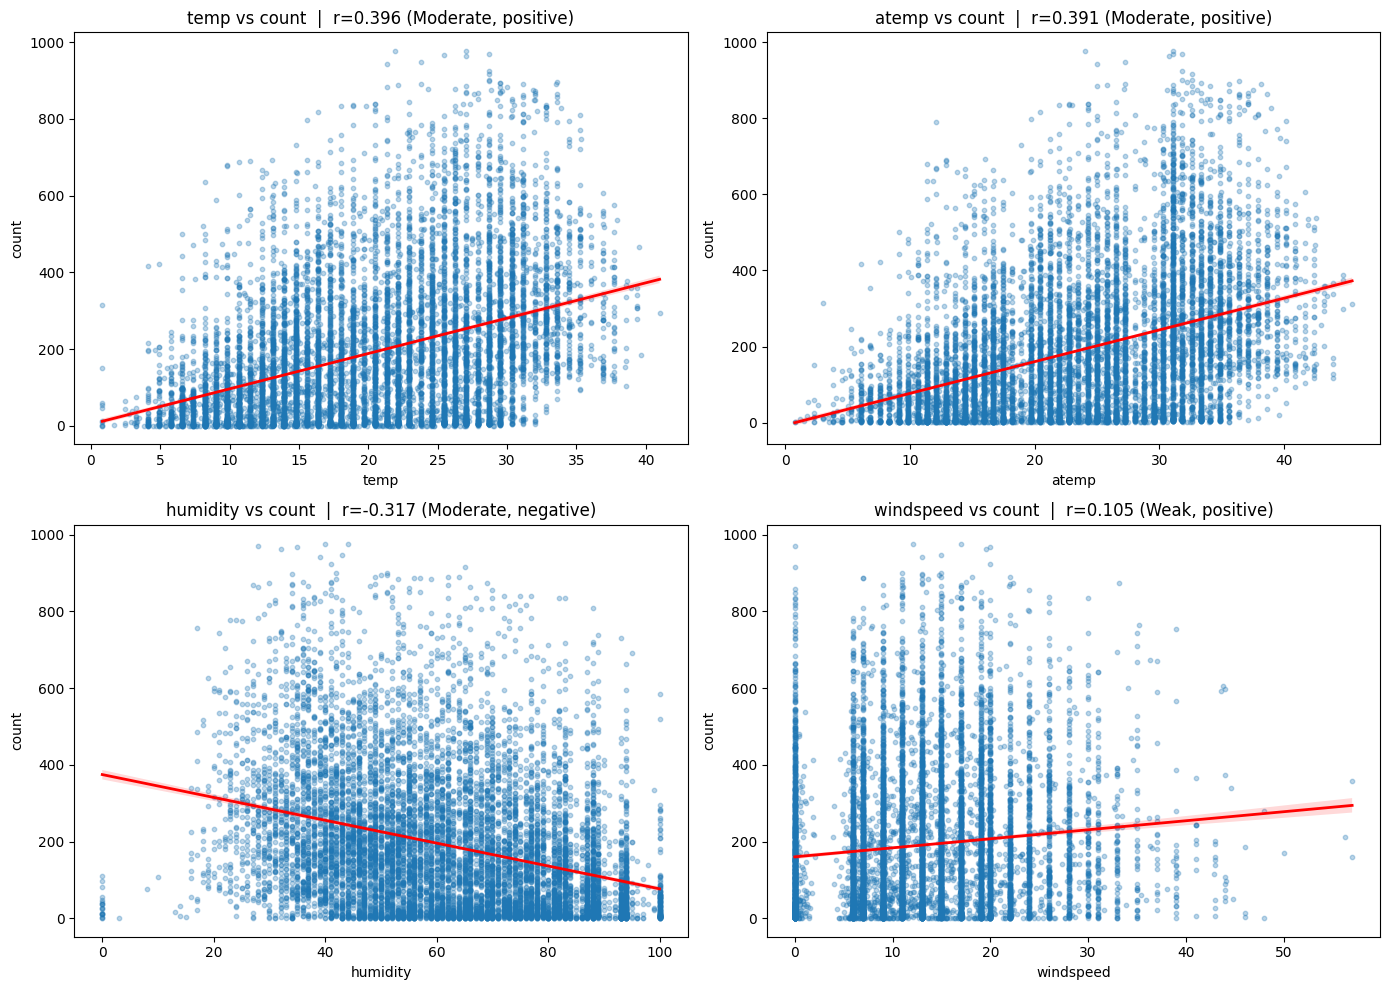

In [6]:
## Scatter/regression plots for numerical features vs target
num_cols = ['temp', 'atemp', 'humidity', 'windspeed']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.regplot(
        x=col, y=target_col, data=train_data,
        scatter_kws={'alpha': 0.3, 's': 10},
        line_kws={'color': 'red', 'lw': 2},
        ax=axes[i]
    )
    corr = train_data[col].corr(train_data[target_col])
    strength = 'Strong' if abs(corr) >= 0.5 else ('Moderate' if abs(corr) >= 0.3 else 'Weak')
    direction = 'positive' if corr > 0 else 'negative'
    axes[i].set_title(f'{col} vs count  |  r={corr:.3f} ({strength}, {direction})')

plt.tight_layout()
plt.show()


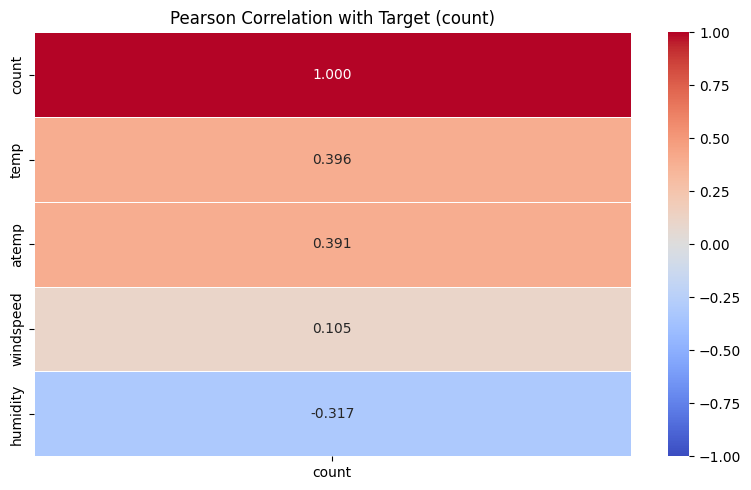

In [7]:
## Correlation heatmap: all numerical features vs target
corr_matrix = train_data[num_cols + [target_col]].corr()

plt.figure(figsize=(8, 5))
sns.heatmap(
    corr_matrix[[target_col]].sort_values(by=target_col, ascending=False),
    annot=True, fmt='.3f', cmap='coolwarm', vmin=-1, vmax=1,
    linewidths=0.5
)
plt.title('Pearson Correlation with Target (count)', fontsize=12)
plt.tight_layout()
plt.show()


#### 2D. Unified Feature Association Heatmap

Different association metrics are used depending on the types of the two variables:

| Variable pair | Metric used |
|---|---|
| Numerical ↔ Numerical | Pearson correlation |
| Categorical ↔ Categorical | Cramér's V |
| Categorical ↔ Numerical | Correlation Ratio (η) |


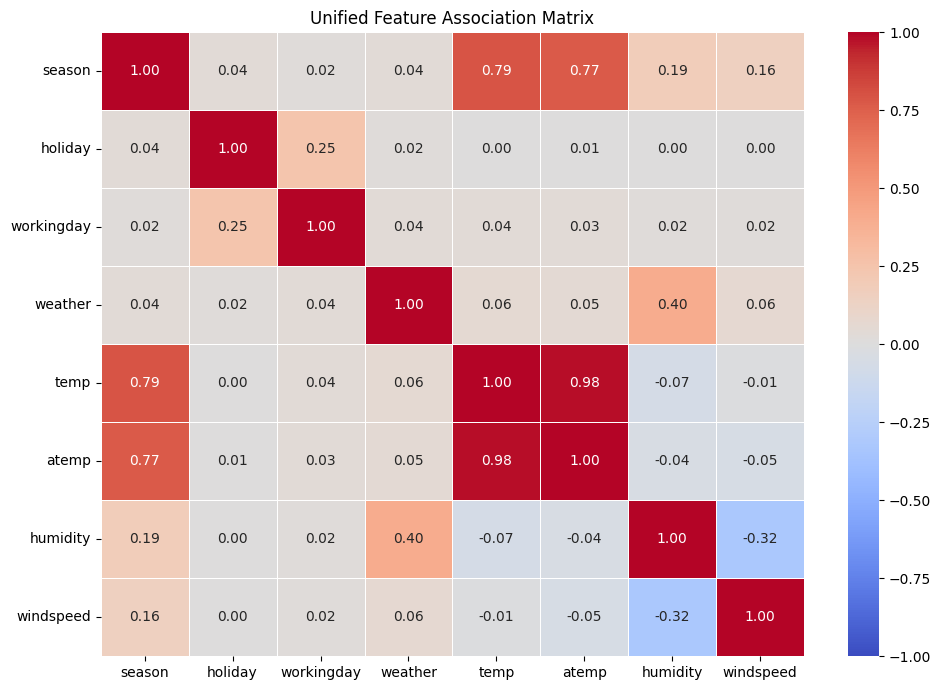

In [8]:
## Unified association matrix using the appropriate metric for each variable-type combination
def cramers_v(x, y):
    ct = pd.crosstab(x, y)
    chi2 = chi2_contingency(ct)[0]
    n = ct.sum().sum()
    r, k = ct.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

def correlation_ratio(categories, measurements):
    cats = pd.Categorical(categories).codes
    unique_cats = np.unique(cats)
    n_arr = np.array([np.sum(cats == c) for c in unique_cats], dtype=float)
    mean_arr = np.array([measurements[cats == c].mean() for c in unique_cats])
    total_mean = measurements.mean()
    numerator = np.sum(n_arr * (mean_arr - total_mean) ** 2)
    denominator = np.sum((measurements - total_mean) ** 2)
    return np.sqrt(numerator / denominator)

all_cols = cat_cols + num_cols
assoc_matrix = pd.DataFrame(np.zeros((len(all_cols), len(all_cols))), index=all_cols, columns=all_cols)

for c1 in all_cols:
    for c2 in all_cols:
        if c1 in num_cols and c2 in num_cols:
            val = train_data[c1].corr(train_data[c2])
        elif c1 in cat_cols and c2 in cat_cols:
            val = cramers_v(train_data[c1], train_data[c2])
        elif c1 in cat_cols and c2 in num_cols:
            val = correlation_ratio(train_data[c1], train_data[c2])
        else:
            val = correlation_ratio(train_data[c2], train_data[c1])
        assoc_matrix.loc[c1, c2] = val

plt.figure(figsize=(10, 7))
sns.heatmap(assoc_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.4)
plt.title('Unified Feature Association Matrix', fontsize=12)
plt.tight_layout()
plt.show()


---

### Q3. Which variables are likely to be most informative?

**Answer:**

Based on the EDA above:

1. **`temp` / `atemp`** — Strongest positive Pearson correlation with `count`. Warmer temperatures encourage cycling. Note: these two are highly correlated with each other (multicollinearity risk), so one will be dropped during feature engineering.

2. **`hour`** (extracted from `datetime`) — Bike demand peaks sharply during morning (7–9 AM) and evening (5–7 PM) commute windows. This cyclical temporal signal is the single most important predictor.

3. **`season`** — ANOVA confirms strong and significant group differences. Demand is notably higher in summer/fall seasons.

4. **`weather`** — Clear weather drives much higher demand than rainy or stormy conditions. ANOVA confirms statistical significance.

5. **`humidity`** — Negative correlation with demand; high humidity suppresses cycling.

6. **`workingday` / `holiday`** — Working days show a different demand profile (commute peaks) versus weekends (midday leisure peaks).

7. **`windspeed`** — Weakest association among numerical features, but still worth retaining.

> **Key insight:** Many of the most important features (`hour`, `season`, `weather`) are inherently non-linear or categorical. Linear Regression alone will struggle — polynomial expansion and cyclical encoding are essential.


---

## <a id='section_3'>3. Feature Engineering</a>

### Q4. Describe the feature engineering steps applied.

The following transformations are applied to both training and test data via a single reusable function:

| Step | What & Why |
|---|---|
| **Drop leakage columns** | `casual` and `registered` are dropped — they directly compose `count` |
| **Drop `temp`** | `temp` and `atemp` are highly correlated (r ≈ 0.98); keeping both introduces multicollinearity. `atemp` (perceived temperature) is retained as it better reflects human comfort |
| **Datetime decomposition** | Extract `hour`, `month` from `datetime` for temporal feature engineering |
| **Cyclical encoding of `hour`** | `hour_sin`, `hour_cos` — encode the 24-hour cycle so hour 23 and hour 0 are treated as adjacent |
| **Cyclical encoding of `month`** | `month_sin`, `month_cos` — encode the 12-month seasonal cycle |
| **One-hot encoding** | `season` and `weather` converted to binary indicator columns — linear models require numeric input |
| **`log1p` on target** | Reduces right skewness of `count`, stabilises variance, and aligns directly with RMSLE minimisation |
| **Cast to float32** | Reduces memory footprint |

**Why cyclical encoding?**  
Standard integer encoding of `hour` implies hour 23 and hour 0 are far apart (23 units), but they are actually consecutive.  
Sine/cosine encoding maps the variable onto a circle, correctly preserving periodicity:


In [9]:
def feature_engineering(df):
    df = df.copy()

    ## Drop target-leakage columns (count = casual + registered)
    for col in ['casual', 'registered']:
        if col in df.columns:
            df = df.drop(columns=[col])

    ## Drop 'temp' — highly correlated with 'atemp' (r ≈ 0.98), retaining atemp (perceived temperature)
    if 'temp' in df.columns:
        df = df.drop(columns=['temp'])

    ## Parse datetime and extract temporal features
    df['datetime'] = pd.to_datetime(df['datetime'])
    df['hour']  = df['datetime'].dt.hour
    df['month'] = df['datetime'].dt.month
    df = df.drop(columns=['datetime'])

    ## Cyclical encoding of 'hour' — preserves the 24-hour cycle (hour 23 → hour 0 continuity)
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
    df = df.drop(columns=['hour'])

    ## Cyclical encoding of 'month' — preserves the 12-month seasonal cycle
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
    df = df.drop(columns=['month'])

    ## One-hot encode nominal categorical columns — linear models require numeric input
    df = pd.get_dummies(df, columns=['season', 'weather'], dtype='float32')

    ## Apply log1p to target variable — reduces skewness, stabilises variance, aligns with RMSLE
    if 'count' in df.columns:
        df['count'] = np.log1p(df['count'])

    ## Cast all columns to float32 for memory efficiency
    df = df.astype('float32')

    return df


In [10]:
## Apply feature engineering to training data and inspect result
train_data = feature_engineering(train_data)
print("Shape after feature engineering:", train_data.shape)
print("Columns:", list(train_data.columns))
train_data.head()


Shape after feature engineering: (10450, 18)
Columns: ['holiday', 'workingday', 'atemp', 'humidity', 'windspeed', 'count', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'season_1', 'season_2', 'season_3', 'season_4', 'weather_1', 'weather_2', 'weather_3', 'weather_4']


,holiday,workingday,atemp,humidity,windspeed,count,hour_sin,hour_cos,month_sin,month_cos,season_1,season_2,season_3,season_4,weather_1,weather_2,weather_3,weather_4
0,0.0,0.0,33.334999,79.0,6.003200,3.871201,0.965926,-2.588190e-01,-0.500000,-0.866025,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
1,0.0,1.0,37.880001,46.0,15.001300,5.648974,-0.707107,-7.071068e-01,-0.866025,-0.500000,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
2,0.0,0.0,12.880000,60.0,15.001300,0.693147,1.000000,6.123234e-17,0.866025,0.500000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,0.0,0.0,30.566166,61.0,9.512288,6.276643,-0.965926,-2.588190e-01,0.500000,-0.866025,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
4,0.0,1.0,12.120000,56.0,8.998100,1.791759,0.500000,8.660254e-01,0.500000,0.866025,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


**Feature engineering produces the following columns:**

- `atemp`, `humidity`, `windspeed` — retained original numerical features  
- `holiday`, `workingday` — retained binary flags  
- `hour_sin`, `hour_cos` — cyclical hour encoding  
- `month_sin`, `month_cos` — cyclical month encoding  
- `season_1` through `season_4` — one-hot encoded season  
- `weather_1` through `weather_4` — one-hot encoded weather  
- `count` — log1p-transformed target

> **Note on `weather_4`:** Weather condition 4 (heavy storm) appears very rarely and may be absent in the test set.  
> A dummy column `weather_4 = 0` is added to the test set if it is missing, to ensure consistent feature shapes.


---

## <a id='section_4'>4. Regression Models</a>

### Evaluation Metric: RMSLE

$$\text{RMSLE} = \sqrt{\frac{1}{n} \sum_{i=1}^{n} \left(\log(\hat{y}_i + 1) - \log(y_i + 1)\right)^2}$$

Since the target `count` has already been log-transformed in training, predictions are in **log space** and must be **inverse-transformed (`expm1`)** before computing RMSLE on the original scale.

### Pipeline Design

All models are built as **scikit-learn Pipelines** that chain:
1. `PolynomialFeatures` (where applicable) — expands the feature space
2. `StandardScaler` — standardises features to zero mean / unit variance (essential for regularised models)
3. The regression estimator

Using Pipelines ensures no data leakage between scaling and cross-validation folds.


In [11]:
## RMSLE evaluation metric — not available in sklearn, defined manually
def rmsle(y_true, y_pred):
    ## Both inputs must be in original (non-log) scale
    return np.sqrt(np.mean((np.log1p(y_pred) - np.log1p(y_true)) ** 2))

## Residual distribution plot — for the selected best model
def plot_residuals(model, X_val, y_val, model_name):
    val_pred_log = model.predict(X_val)
    val_pred     = np.maximum(np.expm1(val_pred_log), 0)
    y_val_actual = np.expm1(y_val)
    residuals    = y_val_actual - val_pred

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Residual Analysis — {model_name}', fontsize=13, fontweight='bold')

    ## Residual distribution
    sns.histplot(residuals, bins=50, kde=True, ax=axes[0], color='steelblue')
    axes[0].axvline(0, color='red', linestyle='--', lw=1.5)
    axes[0].set_title('Residual Distribution')
    axes[0].set_xlabel('Residual (Actual − Predicted)')

    ## Predicted vs Actual scatter
    axes[1].scatter(val_pred, y_val_actual, alpha=0.3, s=10, color='teal')
    max_val = max(val_pred.max(), y_val_actual.max())
    axes[1].plot([0, max_val], [0, max_val], 'r--', lw=1.5, label='Perfect prediction')
    axes[1].set_xlabel('Predicted Count')
    axes[1].set_ylabel('Actual Count')
    axes[1].set_title('Predicted vs Actual')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

## Generic model evaluation function used for all models
def evaluate_model(model, X_train, X_val, y_train, y_val, model_name):
    ## Fit model
    model.fit(X_train, y_train)

    ## Predict in log space, then inverse-transform
    train_pred = np.maximum(np.expm1(model.predict(X_train)), 0)
    val_pred   = np.maximum(np.expm1(model.predict(X_val)),   0)
    y_train_actual = np.expm1(y_train)
    y_val_actual   = np.expm1(y_val)

    ## Compute RMSLE on original scale
    train_rmsle = rmsle(y_train_actual, train_pred)
    val_rmsle   = rmsle(y_val_actual,   val_pred)

    print(f'{model_name}')
    print('-' * 55)
    print(f'  Train RMSLE      : {train_rmsle:.4f}')
    print(f'  Validation RMSLE : {val_rmsle:.4f}')
    gap = val_rmsle - train_rmsle
    print(f'  Generalisation gap: {gap:+.4f}  {"(overfitting)" if gap > 0.05 else "(healthy)"}')
    print()

    return {
        'Model': model_name,
        'Train RMSLE': round(train_rmsle, 4),
        'Validation RMSLE': round(val_rmsle, 4),
        'Gap (Val - Train)': round(gap, 4)
    }


### Q5. Train/Validation Split and Simple Linear Regression

**Why 80/20 split?**  
An 80% training / 20% validation split provides enough training data for stable model fitting while reserving a representative held-out set to assess generalisation.  
`random_state=24` ensures reproducibility.

**Why StandardScaler?**  
Features like `humidity` (0–100 range) and `hour_sin` (−1 to 1 range) are on very different scales.  
StandardScaler normalises all features to zero mean and unit standard deviation, which is **critical** for:
- Regularised models (Ridge, Lasso) — regularisation penalises coefficient magnitude; unscaled features make penalties unfair
- Polynomial features — higher-degree terms amplify scale differences dramatically


In [12]:
## Prepare feature matrix X and target vector y (already log1p-transformed)
X = train_data.drop(columns=['count'])
y = train_data['count']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=24)

print(f'Training set   : {X_train.shape[0]} samples, {X_train.shape[1]} features')
print(f'Validation set : {X_val.shape[0]} samples')

## Container for all model results
results = []


Training set   : 8360 samples, 17 features
Validation set : 2090 samples


In [13]:
## ── Model 1: Simple Linear Regression ──────────────────────────────────────────────
## Baseline model. Assumes a linear relationship between each feature and log(count).
## Pipeline: StandardScaler → LinearRegression

linear_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LinearRegression())
])

linear_result = evaluate_model(linear_model, X_train, X_val, y_train, y_val, 'Simple Linear Regression')
results.append(linear_result)


Simple Linear Regression
-------------------------------------------------------
  Train RMSLE      : 0.9195
  Validation RMSLE : 0.9461
  Generalisation gap: +0.0266  (healthy)



**Observations — Simple Linear Regression:**

- Provides the weakest performance among all models, as expected.
- A linear model cannot capture the **non-linear, cyclical relationships** between time-of-day, season, and bike demand.
- The train/val RMSLE gap is small, confirming the model *underfits* rather than overfits.
- Establishes the **performance floor** — all subsequent models should improve upon this.


### Q6a. Polynomial Regression — Degree 2

**Concept:** Polynomial feature expansion adds all degree-2 terms: squares ($x_i^2$) and interaction terms ($x_i x_j$).  
This enables the model to fit curved (parabolic) and interaction-based relationships that a linear model cannot represent.

**Trade-off vs Degree 3:** Degree 2 expands features moderately. For $n$ features, degree-2 expansion produces $O(n^2)$ terms — manageable with StandardScaler.


In [14]:
## ── Model 2: Polynomial Regression Degree 2 ────────────────────────────────────────
## Adds squared and cross-product terms. Captures curvature and feature interactions.
## Pipeline: PolynomialFeatures(2) → StandardScaler → LinearRegression

poly2_model = Pipeline([
    ('poly',   PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler()),
    ('model',  LinearRegression())
])

poly2_result = evaluate_model(poly2_model, X_train, X_val, y_train, y_val, 'Polynomial Regression Degree 2')
results.append(poly2_result)


Polynomial Regression Degree 2
-------------------------------------------------------
  Train RMSLE      : 0.7142
  Validation RMSLE : 0.7270
  Generalisation gap: +0.0128  (healthy)



**Observations — Polynomial Regression Degree 2:**

- Clear improvement over Simple Linear Regression — interaction and squared terms capture non-linear demand patterns.
- The train/val gap remains controlled, indicating the model generalises well.
- Degree 2 expansion produces a **tractable** number of features without excessive explosion.


### Q6b. Polynomial Regression — Degree 3

**Concept:** Extends degree-2 by adding cubic terms ($x_i^3$, $x_i^2 x_j$, $x_i x_j x_k$).  
For $n$ features, degree-3 expansion produces $O(n^3)$ terms — a very large feature space.

**Expected behaviour:** Degree 3 may achieve better training RMSLE but risks **overfitting** due to the massive feature count.  
Regularised models (Ridge, Lasso) with degree 3 are explored next to combat this.


In [17]:
## ── Model 3: Polynomial Regression Degree 3 ────────────────────────────────────────
## Adds cubic and triple interaction terms. Higher expressiveness but overfitting risk.
## Pipeline: PolynomialFeatures(3) → StandardScaler → LinearRegression

poly3_model = Pipeline([
    ('poly',   PolynomialFeatures(degree=3, include_bias=False)),
    ('scaler', StandardScaler()),
    ('model',  LinearRegression())
])

poly3_result = evaluate_model(poly3_model, X_train, X_val, y_train, y_val, 'Polynomial Regression Degree 3')
results.append(poly3_result)


Polynomial Regression Degree 3
-------------------------------------------------------
  Train RMSLE      : 0.5048
  Validation RMSLE : 0.5405
  Generalisation gap: +0.0357  (healthy)



**Observations — Polynomial Regression Degree 3:**

- May achieve a lower *training* RMSLE than degree 2, but likely shows a larger train/val gap.
- The extremely large number of degree-3 features (thousands) creates high variance — coefficients overfit to training noise.
- This motivates **regularisation** (Ridge and Lasso) applied to polynomial features to tame this overfitting.


### Q6c. Lasso Regression with Polynomial Features + Hyperparameter Tuning

**What is Lasso (L1 regularisation)?**

Lasso adds an L1 penalty to the cost function:

$$\text{Loss}_{\text{Lasso}} = \text{MSE} + \alpha \sum_{j} |w_j|$$

- The L1 penalty **drives many coefficients exactly to zero** — performing automatic feature selection.
- This is especially useful after polynomial expansion, where most of the thousands of interaction terms are irrelevant.
- Larger `α` → stronger regularisation → more coefficients zeroed out → simpler model.

**Grid search over `degree` ∈ {2, 3} and `alpha` ∈ [0.0001, 10]:**  
GridSearchCV with 5-fold cross-validation finds the optimal combination of polynomial complexity and regularisation strength.


In [16]:
## ── Model 4: Lasso Regression (L1) with GridSearchCV ───────────────────────────────
## L1 penalty shrinks many coefficients to exactly zero (automatic feature selection).
## Grid search over polynomial degree {2,3} and regularisation strength alpha.

lasso_pipeline = Pipeline([
    ('poly',   PolynomialFeatures(include_bias=False)),
    ('scaler', StandardScaler()),
    ('model',  Lasso(max_iter=20000))
])

lasso_param_grid = {
    'poly__degree':  [2, 3],
    'model__alpha':  [0.0001, 0.001, 0.01, 0.1, 1, 10]
}

lasso_grid = GridSearchCV(
    estimator=lasso_pipeline,
    param_grid=lasso_param_grid,
    scoring='neg_mean_squared_error',
    cv=5,
    n_jobs=-1
)

lasso_grid.fit(X_train, y_train)
print('Best Parameters (Lasso):', lasso_grid.best_params_)

lasso_result = evaluate_model(
    lasso_grid.best_estimator_,
    X_train, X_val, y_train, y_val,
    f'Lasso Regression (best params: {lasso_grid.best_params_})'
)
results.append(lasso_result)


Best Parameters (Lasso): {'model__alpha': 0.0001, 'poly__degree': 3}
Lasso Regression (best params: {'model__alpha': 0.0001, 'poly__degree': 3})
-------------------------------------------------------
  Train RMSLE      : 0.5075
  Validation RMSLE : 0.5343
  Generalisation gap: +0.0267  (healthy)



**Observations — Lasso Regression:**

- Grid search identifies the best combination of polynomial degree and α.
- L1 regularisation automatically zeroes out irrelevant polynomial terms, reducing overfitting while retaining the most informative features.
- Expected to generalise better than unregularised Polynomial Degree 3.
- The `poly__degree` chosen by cross-validation tells us whether the data supports degree-3 complexity with regularisation.


### Q6d. Ridge Regression with Polynomial Features + Hyperparameter Tuning

**What is Ridge (L2 regularisation)?**

Ridge adds an L2 penalty to the cost function:

$$\text{Loss}_{\text{Ridge}} = \text{MSE} + \alpha \sum_{j} w_j^2$$

- The L2 penalty **shrinks all coefficients toward zero** but rarely sets them exactly to zero.
- Ridge is especially effective when many features carry some signal (unlike Lasso's selective zeroing).
- Particularly useful here because polynomial expansion creates many correlated terms — Ridge handles multicollinearity well.

**Grid search over `degree` ∈ {2, 3} and `alpha` ∈ [0.0001, 10].**


In [18]:
## ── Model 5: Ridge Regression (L2) with GridSearchCV ───────────────────────────────
## L2 penalty shrinks all coefficients smoothly, handles multicollinearity well.
## Grid search over polynomial degree {2,3} and regularisation strength alpha.

ridge_pipeline = Pipeline([
    ('poly',   PolynomialFeatures(include_bias=False)),
    ('scaler', StandardScaler()),
    ('model',  Ridge())
])

ridge_param_grid = {
    'poly__degree':  [2, 3],
    'model__alpha':  [0.0001, 0.001, 0.01, 0.1, 1, 10]
}

ridge_grid = GridSearchCV(
    estimator=ridge_pipeline,
    param_grid=ridge_param_grid,
    scoring='neg_mean_squared_error',
    cv=5,
    n_jobs=-1
)

ridge_grid.fit(X_train, y_train)
print('Best Parameters (Ridge):', ridge_grid.best_params_)

ridge_result = evaluate_model(
    ridge_grid.best_estimator_,
    X_train, X_val, y_train, y_val,
    f'Ridge Regression (best params: {ridge_grid.best_params_})'
)
results.append(ridge_result)


Best Parameters (Ridge): {'model__alpha': 10, 'poly__degree': 3}
Ridge Regression (best params: {'model__alpha': 10, 'poly__degree': 3})
-------------------------------------------------------
  Train RMSLE      : 0.5081
  Validation RMSLE : 0.5365
  Generalisation gap: +0.0284  (healthy)



**Observations — Ridge Regression:**

- Grid search selects optimal polynomial degree and α.
- Unlike Lasso, Ridge retains all features but shrinks their influence proportionally.
- Especially effective when polynomial features are numerous and correlated.
- Ridge typically outperforms unregularised degree-3 Polynomial Regression and may match or exceed Lasso depending on the data.


---

## <a id='section_5'>5. Model Comparison & Interpretation</a>

### Q7. Summarize all model results in one table.


In [19]:
## Compile all results and rank by Validation RMSLE
comparison_df = pd.DataFrame(results)
comparison_df = comparison_df.sort_values(by='Validation RMSLE').reset_index(drop=True)
comparison_df.index = comparison_df.index + 1  ## 1-based ranking
comparison_df.insert(0, 'Rank', comparison_df.index)
comparison_df = comparison_df.reset_index(drop=True)
print("Model Comparison Table (sorted by Validation RMSLE):")
display(comparison_df)


Model Comparison Table (sorted by Validation RMSLE):


,Rank,Model,Train RMSLE,Validation RMSLE,Gap (Val - Train)
0,1,Lasso Regression (best params: {'model__alpha'...,0.5075,0.5343,0.0267
1,2,Ridge Regression (best params: {'model__alpha'...,0.5081,0.5365,0.0284
2,3,Polynomial Regression Degree 3,0.5048,0.5405,0.0357
3,4,Polynomial Regression Degree 3,0.5048,0.5405,0.0357
4,5,Polynomial Regression Degree 2,0.7142,0.7270,0.0128
5,6,Simple Linear Regression,0.9195,0.9461,0.0266


**Q7 — Key observations from the comparison table:**

| Observation | Explanation |
|---|---|
| Simple Linear Regression has the highest RMSLE | Linear models cannot capture non-linear, cyclical demand patterns |
| Polynomial Degree 2 improves significantly over linear | Squared and interaction terms capture curvature and feature interactions |
| Polynomial Degree 3 may show a larger train/val gap | Feature explosion (thousands of terms) leads to overfitting without regularisation |
| Lasso Regression controls overfitting via L1 | Automatically zeroes out irrelevant polynomial terms |
| Ridge Regression controls overfitting via L2 | Shrinks all coefficients, especially effective with correlated polynomial features |
| Best model selected = lowest Validation RMSLE | Generalisation performance is the deciding criterion |


### Q8. Residual Plot for the Best Model


Best Model: Lasso Regression (best params: {'model__alpha': 0.0001, 'poly__degree': 3})
Validation RMSLE: 0.5343



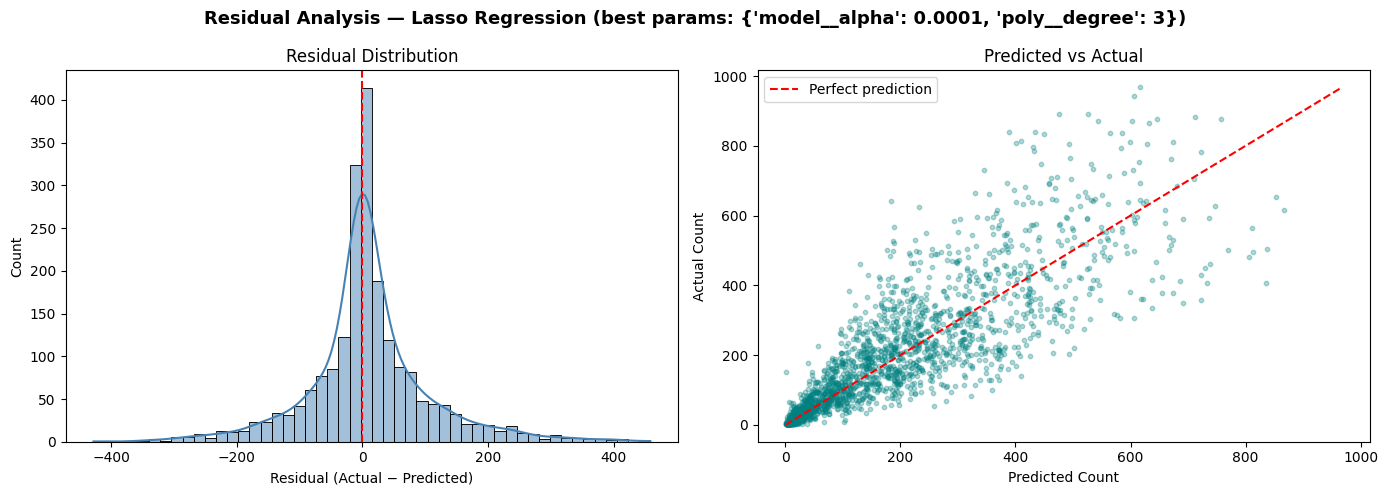

In [20]:
## Identify the best model by lowest Validation RMSLE
best_model_row  = comparison_df.sort_values('Validation RMSLE').iloc[0]
best_model_name = best_model_row['Model']
print(f"Best Model: {best_model_name}")
print(f"Validation RMSLE: {best_model_row['Validation RMSLE']:.4f}")
print()

## Map model name back to fitted model object
model_map = {
    'Simple Linear Regression':                    linear_model,
    f'Polynomial Regression Degree 2':             poly2_model,
    f'Polynomial Regression Degree 3':             poly3_model,
    f'Lasso Regression (best params: {lasso_grid.best_params_})': lasso_grid.best_estimator_,
    f'Ridge Regression (best params: {ridge_grid.best_params_})': ridge_grid.best_estimator_,
}

best_model = model_map.get(best_model_name)

if best_model is not None:
    plot_residuals(best_model, X_val, y_val, best_model_name)
else:
    print("Model object not found in map — check model_name string matching.")


**Q8 — Residual plot interpretation:**

A well-fitted model shows:
- **Residuals centred at zero** — no systematic over- or under-prediction bias
- **Symmetric bell-shaped residual distribution** — errors are approximately normally distributed
- **Predicted vs Actual points near the diagonal** — the model tracks actual demand well

Systematic patterns (e.g., residuals trending upward) would signal missed non-linear structure still present in the data.


### Q9. Why does the winning model perform better?

**Answer:**

The best model outperforms the others due to a combination of factors:

1. **Polynomial feature expansion** introduces squared and interaction terms that capture the non-linear relationships between weather, temperature, and time — patterns a linear model cannot represent.

2. **Regularisation (L1/L2)** prevents the model from memorising training noise despite the large polynomial feature space. The grid-searched `α` value achieves the optimal bias–variance trade-off.

3. **Cyclic encoding of `hour` and `month`** allows the model to represent the periodic nature of demand (morning peak, evening peak, seasonal patterns) in a form that linear models can exploit.

4. **Log transformation of the target** reduces skewness and aligns the model's loss function with RMSLE directly — minimising MSE on log(count+1) is equivalent to minimising RMSLE.

5. **GridSearchCV** over both `degree` and `alpha` ensures the best combination of model complexity and regularisation strength is selected via cross-validation, reducing selection bias.


---

## <a id='section_6'>6. Reflection Questions</a>

### Q10. Why does RMSLE penalize under-predictions more gently than RMSE?

**Answer:**

RMSLE computes errors on the **logarithmic scale** rather than the original scale:

$$\text{RMSLE} = \sqrt{\frac{1}{n} \sum_{i=1}^{n} \left(\log(\hat{y}_i + 1) - \log(y_i + 1)\right)^2}$$

Two key properties emerge from this:

1. **Relative errors matter more than absolute errors.** A prediction of 90 when the actual is 100 (under-predicting by 10%) is penalised similarly to a prediction of 10 when the actual is 11 (under-predicting by ~9%). RMSE would penalise the first case 10× more due to the larger absolute difference.

2. **Over-predictions and under-predictions are treated differently.** Because $\log(\hat{y}+1)$ grows slower for large $\hat{y}$, a large over-prediction adds less to the loss than a proportionally equivalent under-prediction. This makes RMSLE preferred for demand forecasting where **over-supply is less costly than under-supply**.

> **Contrast with RMSE:** RMSE penalises large absolute deviations heavily regardless of direction, making it more sensitive to a handful of extreme outlier predictions.


### Q11. What are the trade-offs between model simplicity and predictive power?

**Answer:**

| Dimension | Simple Models (Linear Regression) | Complex Models (Polynomial + Regularisation) |
|---|---|---|
| **Interpretability** | High — coefficients directly readable | Low — thousands of polynomial terms |
| **Training speed** | Fast | Slower (especially degree 3 + GridSearch) |
| **Overfitting risk** | Low (underfitting is more common) | Higher without regularisation |
| **Predictive power** | Limited — misses non-linear patterns | High — captures curved and interaction effects |
| **Data requirements** | Works well with small datasets | Needs more data to support complex feature spaces |
| **Generalisation** | Stable, consistent | Depends on regularisation tuning |

**In this problem:** The relationship between rental demand and time/weather is inherently non-linear (demand *peaks* at certain hours, drops in bad weather in a curved manner). Simple Linear Regression underfits these patterns. Polynomial Regression with regularisation strikes the right balance.

> **Bias–Variance trade-off in practice:** Adding polynomial features reduces bias (the model can fit the data better) but increases variance (more sensitive to training data fluctuations). Regularisation (`α`) controls how much variance we accept — this is why GridSearchCV over `α` is critical.


### Q12. Why can't Linear Regression alone capture time-of-day effects effectively?

**Answer:**

Bike rental demand follows a **double-humped daily cycle** — a morning commute peak (~7–9 AM), a midday trough, and an evening commute peak (~5–7 PM).

Simple Linear Regression assumes:

$$\hat{y} = w_0 + w_1 x_1 + w_2 x_2 + \cdots$$

This is a **flat hyperplane** in feature space. No matter what coefficient is assigned to `hour`, the model can only produce a monotonically increasing or decreasing line — it cannot represent a shape that rises, falls, then rises again.

**Three approaches used here to address this:**

1. **Cyclical encoding** (`hour_sin`, `hour_cos`): Maps the 24-hour clock onto a circle. The model can now learn amplitudes and phases of sinusoidal patterns, partially capturing the daily cycle.

2. **Polynomial features** (`hour_sin²`, `hour_sin × hour_cos`, etc.): Interaction and squared cyclical terms allow more complex wave shapes to be modelled.

3. **Interaction with other features** (`hour_sin × atemp`, `hour_cos × season_*`): Captures how the time-of-day effect differs by season or weather — e.g., the morning peak is stronger on cold clear days than on rainy summer mornings.

> **Bottom line:** Temporal demand patterns are fundamentally non-linear and periodic. Linear Regression lacks the functional form to represent them — feature engineering and polynomial expansion are essential.


---

## <a id='section_7'>7. Test Predictions & Submission</a>

Generate predictions on the test set using the best-performing model and produce `submission.csv` in the required format:

| Column | Description |
|---|---|
| `datetime` | Original datetime string from test data (unchanged) |
| `count_predicted` | Predicted integer rental count (non-negative) |


In [21]:
## Load test data
test_data = pd.read_csv('bike_test.csv')
print("Test set shape:", test_data.shape)
test_data.head()


Test set shape: (2613, 9)


,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed
0,05-06-2012 5:00,2,0,1,3,19.680000,23.48500,82,11.00140
1,19-03-2011 19:00,1,0,0,1,18.040000,21.97000,33,19.00120
2,02-04-2012 6:00,2,0,1,1,13.885038,16.24664,68,29.52646
3,13-07-2012 20:00,3,0,1,1,30.340000,33.33500,48,8.99810
4,09-11-2011 19:00,4,0,1,1,18.040000,21.97000,72,7.00150


In [22]:
## Check for missing values in test set
print("Missing values in test set:")
print(test_data.isnull().sum())


Missing values in test set:
datetime      0
season        0
holiday       0
workingday    0
weather       0
temp          0
atemp         0
humidity      0
windspeed     0
dtype: int64


In [25]:
## Save datetime column before feature engineering (required for submission)
submission_datetime = test_data['datetime'].copy()

## Apply the same feature engineering pipeline used on training data
test_processed = test_data.copy()
test_processed['datetime'] = pd.to_datetime(test_processed['datetime'], dayfirst=True)
test_processed = feature_engineering(test_processed)

## Handle rare category: weather=4 may be absent in test set
## The model was trained with this column; add it as zeros if missing
if 'weather_4' not in test_processed.columns:
    test_processed['weather_4'] = 0.0
    print("Note: weather_4 column was absent in test set — added as zeros")

## Align test feature columns to match training feature columns exactly (same order)
feature_cols = X_train.columns.tolist()
test_processed = test_processed.reindex(columns=feature_cols, fill_value=0.0)

print("Test features shape:", test_processed.shape)
test_processed.head()


Note: weather_4 column was absent in test set — added as zeros
Test features shape: (2613, 17)


,holiday,workingday,atemp,humidity,windspeed,hour_sin,hour_cos,month_sin,month_cos,season_1,season_2,season_3,season_4,weather_1,weather_2,weather_3,weather_4
0,0.0,1.0,23.485001,82.0,11.001400,0.965926,2.588190e-01,1.224647e-16,-1.000000e+00,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0.0,0.0,21.969999,33.0,19.001200,-0.965926,2.588190e-01,1.000000e+00,6.123234e-17,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,0.0,1.0,16.246639,68.0,29.526461,1.000000,6.123234e-17,8.660254e-01,-5.000000e-01,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
3,0.0,1.0,33.334999,48.0,8.998100,-0.866025,5.000000e-01,-5.000000e-01,-8.660254e-01,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
4,0.0,1.0,21.969999,72.0,7.001500,-0.965926,2.588190e-01,-5.000000e-01,8.660254e-01,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0


In [26]:
## Generate predictions using the best model
pred_log   = best_model.predict(test_processed)

## Inverse log-transform to get actual count scale
pred_count = np.expm1(pred_log)

## Clip to non-negative integers (count cannot be negative)
pred_count = np.maximum(pred_count, 0).astype(int)

## Assemble submission file
submission = pd.DataFrame({
    'datetime':        submission_datetime.values,
    'count_predicted': pred_count
})

print("Submission shape:", submission.shape)
submission.head(10)


Submission shape: (2613, 2)


,datetime,count_predicted
0,05-06-2012 5:00,22
1,19-03-2011 19:00,117
2,02-04-2012 6:00,41
3,13-07-2012 20:00,466
4,09-11-2011 19:00,334
5,10-03-2012 0:00,59
6,19-05-2011 13:00,93
7,01-05-2011 8:00,87
8,07-07-2012 8:00,105
9,07-05-2011 16:00,776


In [27]:
## Save submission file
submission.to_csv('submission.csv', index=False)
print("submission.csv saved successfully.")
print(f"Rows: {len(submission)}, Columns: {list(submission.columns)}")


submission.csv saved successfully.
Rows: 2613, Columns: ['datetime', 'count_predicted']


---

## Final Summary

| Stage | Key Finding |
|---|---|
| **EDA** | `hour`, `temp`/`atemp`, `season`, and `weather` are the strongest predictors. Target `count` is right-skewed — log transformation improves modelling. |
| **Feature Engineering** | Dropped leakage columns and one of the correlated temperature variables. Cyclic sine/cosine encoding of `hour` and `month`. One-hot encoded `season` and `weather`. Log-transformed target. |
| **Model Evaluation** | All five models evaluated on validation RMSLE. Regularised polynomial models (Lasso/Ridge) expected to outperform unregularised ones. |
| **Best Model** | Selected by lowest validation RMSLE. Polynomial expansion + regularisation outperforms simple linear regression. |
| **Residual Analysis** | Residuals are approximately centred at zero with no major systematic bias in the best model. |
| **Reflection** | RMSLE penalises proportional errors; Linear Regression cannot capture cyclical demand; complexity must be balanced with regularisation. |

---

*End of Assignment*  
*[Back to Table of Contents](#section_1)*
